In [1]:
################################################################################
# Version 0.0    $Revision: 1 $
# $Author: tbadea
#
#    Copyright ? 1996 - 2008 by IXIA
#    All Rights Reserved.
#
#    Revision Log:
#    03-09-2014 Daria Badea
#
################################################################################

################################################################################
#                                                                              #
#                                LEGAL  NOTICE:                                #
#                                ==============                                #
# The following code and documentation (hereinafter "the script") is an        #
# example script for demonstration purposes only.                              #
# The script is not a standard commercial product offered by Ixia and have     #
# been developed and is being provided for use only as indicated herein. The   #
# script [and all modifications, enhancements and updates thereto (whether     #
# made by Ixia and/or by the user and/or by a third party)] shall at all times #
# remain the property of Ixia.                                                 #
#                                                                              #
# Ixia does not warrant (i) that the functions contained in the script will    #
# meet the user's requirements or (ii) that the script will be without         #
# omissions or error-free.                                                     #
# THE SCRIPT IS PROVIDED "AS IS" WITHOUT WARRANTY OF ANY KIND, AND IXIA        #
# DISCLAIMS ALL WARRANTIES, EXPRESS, IMPLIED, STATUTORY OR OTHERWISE,          #
# INCLUDING BUT NOT LIMITED TO ANY WARRANTY OF MERCHANTABILITY AND FITNESS FOR #
# A PARTICULAR PURPOSE OR OF NON-INFRINGEMENT.                                 #
# THE ENTIRE RISK AS TO THE QUALITY AND PERFORMANCE OF THE SCRIPT  IS WITH THE #
# USER.                                                                        #
# IN NO EVENT SHALL IXIA BE LIABLE FOR ANY DAMAGES RESULTING FROM OR ARISING   #
# OUT OF THE USE OF, OR THE INABILITY TO USE THE SCRIPT OR ANY PART THEREOF,   #
# INCLUDING BUT NOT LIMITED TO ANY LOST PROFITS, LOST BUSINESS, LOST OR        #
# DAMAGED DATA OR SOFTWARE OR ANY INDIRECT, INCIDENTAL, PUNITIVE OR            #
# CONSEQUENTIAL DAMAGES, EVEN IF IXIA HAS BEEN ADVISED OF THE POSSIBILITY OF   #
# SUCH DAMAGES IN ADVANCE.                                                     #
# Ixia will not be required to provide any software maintenance or support     #
# services of any kind (e.g., any error corrections) in connection with the    #
# script or any part thereof. The user acknowledges that although Ixia may     #
# from time to time and in its sole discretion provide maintenance or support  #
# services for the script, any such services are subject to the warranty and   #
# damages limitations set forth herein and will not obligate Ixia to provide   #
# any additional maintenance or support services.                              #
#                                                                              #
################################################################################

################################################################################
#                                                                              #
# Description:                                                                 #
# This script configures a scenario with 1 topologies:		                   #
#        - Topology 0 with LAC and DHCPv6 Client							   #
#        - Topology 1 with LNS and DHCPv6 Server 							   #
# The script does:										                       #
#    	 - start/stop protocol												   #
#		 - collect and display DHCP statistics       						   #
#																			   #
# Module:                                                                      #
#    The sample was tested on a 9GE LSM XM3 module.                           #
#                                                                              #
################################################################################

import sys, os
import time, re

# Append paths to python APIs

# sys.path.append('/path/to/hltapi/library/common/ixiangpf/python')
# sys.path.append('/path/to/ixnetwork/api/python')

from ixiatcl import IxiaTcl
from ixiahlt import IxiaHlt
from ixiangpf import IxiaNgpf
from ixiaerror import IxiaError
from pprint import pprint

ixiatcl = IxiaTcl()
ixiahlt = IxiaHlt(ixiatcl)
ixiangpf = IxiaNgpf(ixiahlt)

try:
	ixnHLT_errorHandler('', {})
except (NameError,):
	def ixnHLT_errorHandler(cmd, retval):
		global ixiatcl
		err = ixiatcl.tcl_error_info()
		log = retval['log']
		additional_info = '> command: %s\n> tcl errorInfo: %s\n> log: %s' % (cmd, err, log)
		raise IxiaError(IxiaError.COMMAND_FAIL, additional_info)

def print_dict(obj, nested_level=-1, output=sys.stdout):
    """
    Print each dict key with indentions for readability.
    """
    spacing = '   '
    if type(obj) == dict:
        print(  '%s' % ((nested_level) * spacing))
        for k, v in obj.items():
            if hasattr(v, '__iter__'):
                print('%s%s:' % ((nested_level + 0) * spacing, k) )
                print_dict(v, nested_level + 0, output)
            else:
                print( '%s%s: %s' % ((nested_level + 0) * spacing, k, v))

        print( '%s' % (nested_level * spacing))
    elif type(obj) == list:
        print('%s[' % ((nested_level) * spacing))
        for v in obj:
            if hasattr(v, '__iter__'):
                print_dict(v, nested_level + 0, output)
            else:
                print( '%s%s' % ((nested_level + 0) * spacing, v))
        print('%s]' % ((nested_level) * spacing))
    else:
        print('%s%s' % (nested_level * spacing, obj))


import yaml
def load_config(config_file_path):
    with open(config_file_path, 'r') as file:
        try:
            # Use safe_load to safely parse the YAML content
            config_data = yaml.safe_load(file)
            return config_data
        except yaml.YAMLError as exc:
            print(exc)
            return None

#cwd = os.getcwd()
#print(cwd)
#os.chdir(os.path.dirname(os.path.abspath(__file__)))
config=load_config('ixnetwork_config.yaml')

ixiatcl:info: Tcl version: 8.6.12
Tcl 8.6 is installed on 64bit architecture.
Using products based on: HLTSET289
IxTclHal is not be used for current HLTSET.
Loaded IxTclNetwork 26.0.2601.6
Mpexpr is not installed.
HLT release 26.0.2601.5
Loaded ixia_hl_lib-26.0 


In [3]:


ixia_tcl = IxiaTcl()
ixia_hlt = IxiaHlt(ixia_tcl)
ixia_ngpf = IxiaNgpf(ixia_hlt)
ixNet = ixia_ngpf.ixnet ;# For low level Python API commands

ixnetwork_tcl_server = config['session']['IpAddress']

chassis_ip = config['portMap'][-1]['IpAddress']
port_list = [
             str(config['portMap'][-1]['CardId'])+'/'+str(config['portMap'][0]['PortId']),
             str(config['portMap'][0]['CardId'])+'/'+str(config['portMap'][1]['PortId'])
            ]
cfgErrors = -1
#chassis_ip              = '9.205.15.184'
#ixnetwork_tcl_server    = 'localhost'
#port_list               = '8/1 9/9'


# #############################################################################
# 								CONNECT AND PORT HANDLES
# #############################################################################

print('\n\nConnect to IxNetwork Tcl Server and get port handles...\n\n')

connect_status = ixiangpf.connect(
	reset                  = 0,
    device                 = chassis_ip,
	port_list              = port_list,
	ixnetwork_tcl_server   = ixnetwork_tcl_server,
	#tcl_server             = chassis_ip,
    user_name=config['session']['UserName'],
    user_password=config['session']['Password']
)
if connect_status['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('connect', connect_status)

port_handle = connect_status['vport_list']
port_1 = port_handle.split(' ')[0]
port_0 = port_handle.split(' ')[1]

ports = port_handle.split()
result = ixiangpf.interface_config(
    mode='config',
    port_handle = ports,
    phy_mode = ['fiber', 'fiber']
)


ixiatcl:info: Tcl version: 8.6.12
Tcl 8.6 is installed on 64bit architecture.
Using products based on: HLTSET289
IxTclHal is not be used for current HLTSET.
Loaded IxTclNetwork 26.0.2601.6
Mpexpr is not installed.
HLT release 26.0.2601.5
Loaded ixia_hl_lib-26.0 


Connect to IxNetwork Tcl Server and get port handles...


Connecting to IxNetwork Tcl Server 10.36.94.225 -apiKey dcb192039b704f44913415767cc0eacf -clientId {HLAPI-Tcl} ...
ixiangpf:info: [04/23/2026 08:32:04    info] COMPLETED: interface_config               : PASS


In [4]:


 ####################### Create Topologies ###################################

topology_status = ixiangpf.topology_config(
    topology_name           =   "DHCPv4 Client"                    ,
    port_handle             =   port_0                             ,
    device_group_multiplier =    '10'                                 ,
)
if topology_status['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('topology_config', topology_status)

print( "Configured topology 1" )

deviceGroup_first_handle = topology_status ['device_group_handle']
top_1 = topology_status['topology_handle']



 ########################### Topology 2 ###################################

topology_status = ixiangpf.topology_config(
    topology_name            =	"DHCPv4 Server"                     ,
    port_handle              =	port_1    	                        ,
    device_group_multiplier  =	 	'1'		                        ,
)
if topology_status['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('topology_config', topology_status)

print( "Configured topology 2" )

deviceGroup_second_handle = topology_status['device_group_handle']
top_handle = topology_status['topology_handle']
top_2 = topology_status['topology_handle']

################################################################################
#                          Configure dhcp_client and server                    #
################################################################################

 ############## configure dhcp client ##############################

dhcp_status = ixiangpf.emulation_dhcp_group_config(
	 handle      =  deviceGroup_first_handle                         ,
	 protocol_name 		=		"Dhcp_client"                     ,
	 #mac_addr  =   '0000.0000.ffff'                                        ,
	 mac_addr  =   '00.11.01.00.00.01'                                        ,
	 mac_addr_step		=		'00.00.00.00.00.01'	                  ,
	 use_rapid_commit = '0'                                              ,
	 enable_stateless = '0'                                              ,
     num_sessions     =  '30'                                           ,
     vlan_id		=				'100'			                      ,
     vlan_id_step		=			'0'			                      ,
     vlan_user_priority		=		'2'			                  ,
     dhcp4_broadcast   = '1'                                            ,
     dhcp_range_use_first_server = '1'                                   ,
     dhcp_range_renew_timer = '20'                                       ,
     dhcp_range_ip_type       =      'ipv4'                             ,
     vendor_id                =          'any'                          ,
)
if dhcp_status['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('emulation_dhcp_group_config', dhcp_status)

dhcp_client = dhcp_status['dhcpv4client_handle']

dhcp_status = ixiangpf.emulation_dhcp_config(
	handle 			=	dhcp_client                             ,
	mode			=		'modify'	                                 ,
	release_rate	=			'65'	                                 ,
	msg_timeout		=		'5'	                                 ,
	request_rate	=			'7'	                                 ,
	retry_count		=		'2'	                                 ,
	interval_stop	=			'5'	                                 ,
	interval_start		=		'6'	                                 ,
	min_lifetime		=		'10'	                                 ,
	max_restarts		=		'20'	                                 ,
	max_lifetime		=		'30'	                                 ,
	enable_restart		=		'1'	                                 ,
	enable_lifetime		=	'0'	                                 ,
    client_port             =       '68'                              ,
    skip_release_on_stop    =       '1'                                ,
    renew_on_link_up        =       '1'                                ,
)
if dhcp_status['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('emulation_dhcp_config', dhcp_status)

############## configure dhcp server ##############################


dhcp_status = ixiangpf.emulation_dhcp_server_config(
		handle				=	deviceGroup_second_handle              ,
		count				=	'5'			                            ,
		lease_time             =   '86400'                                ,
		ipaddress_count		=	'10'			                        ,
		ip_dns1		=		'0.0.0.0'		                        ,
		ip_dns1_step	=			'0.0.0.1'			                    ,
		ip_dns2		=		'0.0.0.0'		                        ,
		ip_dns2_step	=			'0.0.1.0'			                    ,
		ipaddress_pool		=		'100.1.0.3'	                    ,
		ipaddress_pool_step		=	'0.0.1.0'			                ,
		ipaddress_pool_prefix_length =		'24'			                ,
		ipaddress_pool_prefix_step	=	'1'			                    ,
		dhcp_offer_router_address	=	'0.0.0.0'	                ,
		dhcp_offer_router_address_step 	= '0.0.0.1'			            ,
		ip_address		=		'100.1.0.2'			                        ,
		ip_step		=		'0.0.1.0'			                        ,
		ip_gateway		=		'100.1.0.1'			                        ,
		ip_gateway_step		=	'0.0.1.0'			                    ,
		ip_prefix_length	=		'24'			                        ,
		ip_prefix_step		=		'1'			                        ,
		local_mac              =         '00.12.01.00.00.01'                 ,
       	local_mac_outer_step   =       '0000.0000.0001'                   ,
		local_mtu		=		'1500'			                            ,
		vlan_id			=		'100'			                        ,
		vlan_id_step		=		'10'			                        ,
		protocol_name		=	"DHCP4 Server modified"                   ,
		use_rapid_commit		=	'1'			                        ,
		pool_address_increment	=	'0.0.0.1'		                    ,
		pool_address_increment_step =		'0.0.0.0'			            ,
		ping_timeout		=		'10'			                        ,
		ping_check		=		'1'			                            ,
        echo_relay_info     =       '1'                                   ,
		enable_resolve_gateway	=	'0'								  	,
		manual_gateway_mac	=	    '00bd.2340.0000'					  	,
		manual_gateway_mac_step =	'0000.0000.0001'					  	,
)
if dhcp_status['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('emulation_dhcp_server_config', dhcp_status)

dhcp_server = dhcp_status['dhcpv4server_handle']

################################################################################
#                          Modify dhcp server                                    #
################################################################################

#dhcp_status = ixiangpf.emulation_dhcp_server_config(
#		handle			=			dhcp_server    ,
#        mode      = 'modify'                          ,
#        lease_time  =               '86400'           ,
#		ipaddress_count		=	'10'		        ,
#		ipaddress_pool		=		'100.1.0.3'       ,
#		ipaddress_pool_step	=	'0.0.0.1'         ,
#		ipaddress_pool_prefix_length =	'24'          ,
#		protocol_name		=		"Dhcpv4_Server" ,
#)
#if dhcp_status['status'] != IxiaHlt.SUCCESS:
#	ixnHLT_errorHandler('emulation_dhcp_server_config', dhcp_status)



ixiangpf:info: [04/23/2026 08:33:27    info] COMPLETED: topology_config                : PASS
Configured topology 1
ixiangpf:info: [04/23/2026 08:33:27    info] COMPLETED: topology_config                : PASS
Configured topology 2
ixiangpf:info: [04/23/2026 08:33:28    info] COMPLETED: emulation_dhcp_group_config    : PASS
ixiangpf:info: [04/23/2026 08:33:28    info] COMPLETED: emulation_dhcp_config          : PASS
ixiangpf:info: [04/23/2026 08:33:29    info] COMPLETED: emulation_dhcp_server_config   : PASS


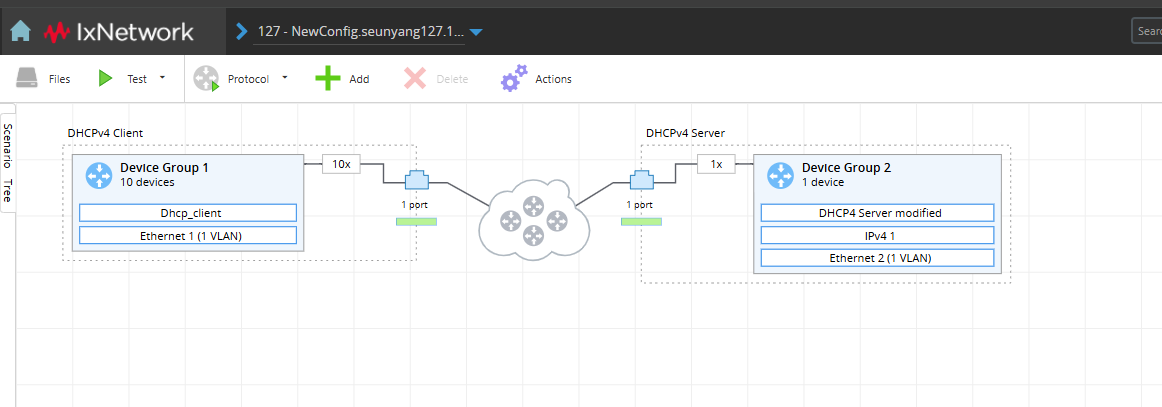

In [5]:
################################################################################
#                          start dhcp_client and server                        #
################################################################################
print( "Starting dhcp server...." )
control_status = ixiangpf.emulation_dhcp_server_control(
	dhcp_handle = 			dhcp_server 		                           ,
	action = 'collect'								                           ,
)
if control_status['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('emulation_dhcp_server_control', control_status)

print( "Starting dhcp client...." )
control_status = ixiangpf.emulation_dhcp_control(
	handle 			=	dhcp_client                            ,
	action = 'bind'						                            ,
)
if control_status['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('emulation_dhcp_control', control_status)

time.sleep(30)

################################################################################
#                       Retrieve statistics                                    #
################################################################################
print( "Retrieve statistics" )
dhcp_stats_0 = ixiangpf.emulation_dhcp_server_stats(
    port_handle   = port_1	                                           ,
	action 	= 'collect'				                                   ,
    execution_timeout = '60'                                              ,
)
if dhcp_stats_0['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('emulation_dhcp_server_stats', dhcp_stats_0)

print( "\n\nDHCP Server aggregate statistics:\n\n" )
pprint(dhcp_stats_0)

dhcp_stats_0 = ixiangpf.emulation_dhcp_server_stats(
	dhcp_handle   = dhcp_server	                                           ,
	action =	'collect'				                                       ,
    execution_timeout = '60'                                                  ,
)
if dhcp_stats_0['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('emulation_dhcp_server_stats', dhcp_stats_0)

print( "\n\nDHCP Server per session statistics:\n\n" )
pprint(dhcp_stats_0)

dhcp_stats_0 = ixiangpf.emulation_dhcp_stats(
        port_handle  = port_0	                                    ,
		mode         = 'aggregate_stats'					            ,
		dhcp_version =	'dhcp4'				                        ,
        execution_timeout = '60'                                       ,
)
if dhcp_stats_0['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('emulation_dhcp_stats', dhcp_stats_0)

print( "\n\nDHCP Client aggregate statistics:\n\n" )
pprint(dhcp_stats_0)

dhcp_stats_0 = ixiangpf.emulation_dhcp_stats(
	handle  = dhcp_client	                                        ,
	mode     =     'aggregate_stats'					                ,
	dhcp_version =	'dhcp4'				                            ,
    execution_timeout = '60'                                           ,
)
if dhcp_stats_0['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('emulation_dhcp_stats', dhcp_stats_0)

print( "\n\nDHCP Client aggregate statistics:\n\n" )
pprint(dhcp_stats_0)

dhcp_stats_0 = ixiangpf.emulation_dhcp_stats(
        handle   = dhcp_client	                                    ,
		mode       =    'session'					                    ,
		dhcp_version  =	'dhcp4'				                        ,
        execution_timeout  = '60'                                       ,
)
if dhcp_stats_0['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('emulation_dhcp_stats', dhcp_stats_0)

print( "\n\nDHCP Client per session statistics:\n\n" )
pprint(dhcp_stats_0)

################################################################################
#                       Stop protocols                                         #
################################################################################
 ############ stop server ################

print( "Stopping server...." )

control_status = ixiangpf.emulation_dhcp_server_control(
	dhcp_handle 	=		dhcp_server 		                           ,
	action = 'abort'								                           ,
)
if control_status['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('emulation_dhcp_server_control', control_status)

 ############ stop all protocol on port 1#####################
stop_item_status = ixiangpf.test_control(
	action	= 'stop_protocol'		                                    ,
	handle	= deviceGroup_second_handle                              ,
)
if stop_item_status['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('test_control', stop_item_status)

print("Stop protocol deviceGroup_second_handle")
pprint(stop_item_status)
time.sleep(10)

 ################ stop client ###################################
print( "Stopping client...." )

control_status = ixiangpf.emulation_dhcp_control(
	handle 			=	dhcp_client                             ,
	action = 'abort'						                             ,
)
if control_status['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('emulation_dhcp_control', control_status)

stop_item_status = ixiangpf.test_control(
	action	= 'stop_protocol'		                                    ,
	handle	= deviceGroup_first_handle                             ,
)
if stop_item_status['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('test_control', stop_item_status)

print("Stop protocol deviceGroup_first_handle")
pprint(stop_item_status)
time.sleep(1)

################################################################################
#                       delete topology                                        #
################################################################################

time.sleep(10)

 ######### delete dhcp client ###########################
print( "Deleting dhcp server topology..." )

dhcp_status = ixiangpf.emulation_dhcp_server_config(
	handle 		=		dhcp_server                                ,
	mode			=		'reset'	                                    ,
)
if dhcp_status['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('emulation_dhcp_server_config', dhcp_status)

 ########### delete dhcp server ############################
print( "Deleting dhcp client topology..." )

dhcp_status = ixiangpf.emulation_dhcp_group_config(
	handle 			=	dhcp_client                               ,
	mode			=		'reset'	                                   ,
)
if dhcp_status['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('emulation_dhcp_group_config', dhcp_status)

############## delete both topology ###################################

topology_status = ixiangpf.topology_config(
    mode                    =   'destroy'                             ,
    topology_name           =   "DHCPv4 Client"                     ,
    topology_handle          =   top_1                             ,
    device_group_multiplier  =   '10'                                 ,
    device_group_enabled     =   '0'                                  ,
    device_group_handle      =   deviceGroup_first_handle          ,
)
if topology_status['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('topology_config', topology_status)

topology_status = ixiangpf.topology_config(
    mode                    =   'destroy'                             ,
    topology_name           =   "DHCPv4 Server"                     ,
    topology_handle         =    top_2                             ,
    device_group_multiplier =    '10'                                 ,
    device_group_enabled    =    '0'                                  ,
    device_group_handle     =    deviceGroup_second_handle         ,
)
if topology_status['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('topology_config', topology_status)

# #############################################################################
# 								CLEANUP SESSION
# #############################################################################

cleanup_status = ixiangpf.cleanup_session(reset='1')
if cleanup_status['status'] != IxiaHlt.SUCCESS:
	ixnHLT_errorHandler('cleanup_session', cleanup_status)

print('\n\nIxNetwork session is closed...\n\n')
print('!!! TEST is PASSED !!!')



Starting dhcp server....
ixiangpf:info: [04/23/2026 08:39:02    info] COMPLETED: emulation_dhcp_server_control  : PASS
Starting dhcp client....
ixiangpf:info: [04/23/2026 08:39:02    info] COMPLETED: emulation_dhcp_control         : PASS
Retrieve statistics
ixiangpf:info: [04/23/2026 08:39:46    info] COMPLETED: emulation_dhcp_server_stats    : PASS


DHCP Server aggregate statistics:


{'aggregate': {'1/1/3': {'current_leases_allocated': '10',
                         'port_name': '1/1/3',
                         'rx': {'decline': '0',
                                'discover': '16',
                                'inform': '0',
                                'release': '0',
                                'request': '10'},
                         'session_total': '1',
                         'sessions_down': '0',
                         'sessions_not_started': '0',
                         'sessions_up': '1',
                         'total_leases_allocated': '10',
           

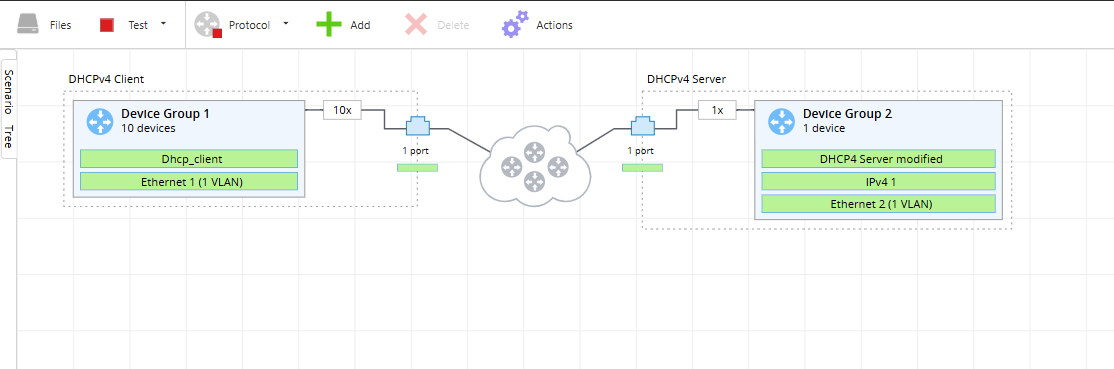